In [2]:
# !pip install huggingface_hub

In [ ]:
# from huggingface_hub import hf_hub_download

# # 2. Download sam3.pt
# model_path = hf_hub_download(
#     repo_id="facebook/sam3",
#     filename="sam3.pt",
#     token="YOUR_HF_TOKENS",
#     local_dir="."  # Downloads to current directory
# )

# print(f"File downloaded to: {model_path}")

In [34]:
import requests
from PIL import Image

# --- Configuration ---
# Replace this with your actual Cloud Run URL
# IMPORTANT: Ensure the URL ends with /predict
API_URL = "https://sam3-app-1040077537378.us-east4.run.app/predict"

# Local image path and prompt
IMAGE_PATH = "./generated_image_1768930074.png"  # Change to your image path
PROMPT = ["human", "pizza"]                   # Change to your prompt

def run_cloud_inference(image_path, prompt, api_url):
    """
    Reads a local image, uploads it to Cloud Run, and decodes the response.
    """
    print(f"Sending request to {api_url}...")
    
    # 1. Prepare the payload
    # We open the file in binary mode ('rb')
    try:
        with open(image_path, "rb") as f:
            # 'file' key matches the server's: file: UploadFile = File(...)
            files = {"file": f}
            
            # 'prompt' key matches the server's: prompt: str = Form(...)
            data = {"prompt": prompt}
            
            # 2. Send POST request
            # requests library automatically handles the multipart/form-data headers
            response = requests.post(api_url, files=files, data=data)
            
            # 3. Check for errors
            if response.status_code != 200:
                print(f"Error {response.status_code}: {response.text}")
                return None
            
            # 4. Parse JSON response
            return response.json()
            
    except FileNotFoundError:
        print(f"Error: Could not find file at {image_path}")
        return None
    except Exception as e:
        print(f"Connection Error: {e}")
        return None

# --- Main Execution ---
result = run_cloud_inference(IMAGE_PATH, PROMPT, API_URL)

Sending request to https://sam3-app-1040077537378.us-east4.run.app/predict...


In [35]:
result.keys()

dict_keys(['boxes', 'scores', 'mask_shape', 'masks_base64'])

In [36]:
result['boxes']

[[145.5521697998047, 638.103271484375, 480.65118408203125, 738.6475830078125],
 [85.87879943847656, 523.999755859375, 191.2292938232422, 600.0665283203125],
 [237.66604614257812, 519.6904296875, 324.2495422363281, 565.620849609375]]

In [37]:
result['mask_shape']

[3, 1, 1024, 1024]

In [38]:
len(result['masks_base64'])

3

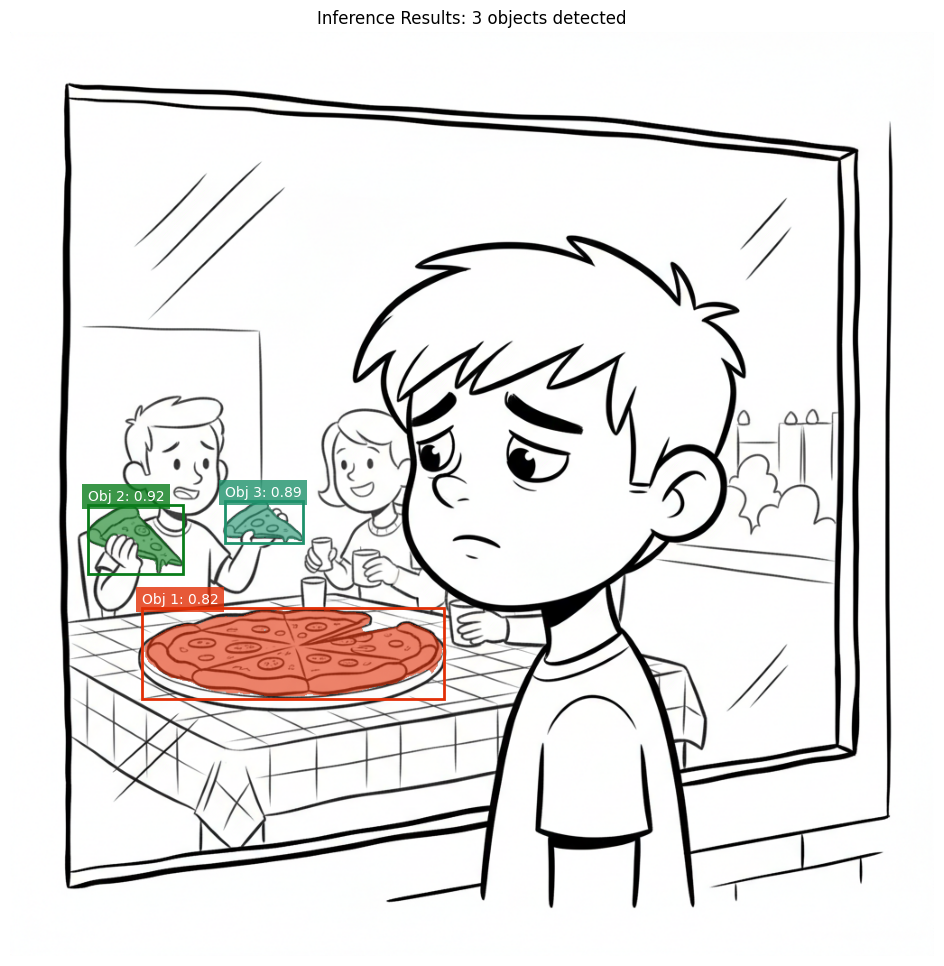

In [39]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from PIL import Image
import base64
import io
import random

try:
    original_image = Image.open(IMAGE_PATH).convert("RGB")
except FileNotFoundError:
    print(f"Could not find image at {IMAGE_PATH}. Please check the path.")
    # Create a dummy black image just to prevent code crash if file missing
    original_image = Image.new("RGB", (1024, 1024), (0, 0, 0))

# 2. Prepare Data
boxes = result['boxes']
masks_b64 = result['masks_base64']
scores = result['scores']

# 3. Visualization Function
def show_inference_results(image, boxes, masks_b64, scores):
    plt.figure(figsize=(12, 12))
    plt.imshow(image)
    ax = plt.gca()
    
    # Iterate over all detections
    for i, (box, mask_str, score) in enumerate(zip(boxes, masks_b64, scores)):
        
        # --- A. Decode and Process Mask ---
        # Decode base64 string to bytes
        mask_bytes = base64.b64decode(mask_str)
        # Open as PIL image
        mask_pil = Image.open(io.BytesIO(mask_bytes))
        # Convert to numpy array (0 to 255)
        mask_arr = np.array(mask_pil)
        
        # Create a colored overlay for the mask
        # We create an RGBA image where A (alpha) controls transparency
        color = np.concatenate([np.random.random(3), [0.6]]) # Random RGB + 0.6 Alpha
        h, w = mask_arr.shape
        mask_overlay = np.zeros((h, w, 4))
        
        # Where mask is white (>0), apply the color
        mask_bool = mask_arr > 0
        mask_overlay[mask_bool] = color

        # Display the mask overlay
        ax.imshow(mask_overlay)

        # --- B. Draw Bounding Box ---
        # Box format is [x1, y1, x2, y2]
        x1, y1, x2, y2 = box
        width = x2 - x1
        height = y2 - y1
        
        # Create a Rectangle patch
        # Use the same color for the box border as the mask, but fully opaque
        box_color = color[:3] 
        rect = patches.Rectangle(
            (x1, y1), width, height, 
            linewidth=2, 
            edgecolor=box_color, 
            facecolor='none'
        )
        ax.add_patch(rect)

        # --- C. Add Label ---
        label = f"Obj {i+1}: {score:.2f}"
        ax.text(
            x1, y1 - 5, label, 
            color='white', 
            fontsize=10, 
            bbox=dict(facecolor=box_color, alpha=0.8, edgecolor='none')
        )

    plt.axis('off')
    plt.title(f"Inference Results: {len(boxes)} objects detected")
    plt.show()

# 4. Run Visualization
show_inference_results(original_image, boxes, masks_b64, scores)